# Transfer Learning with 5-Fold Cross Validation

이 노트북은 사전학습된 DNN 모델을 LIME 데이터셋으로 전이학습하고, `k=5` 교차검증으로 검증한 뒤 고정 테스트셋 `test_lime.csv`에서 성능과 예측 결과를 확인합니다.

## 실험 설정

- 학습 풀: `mof/dataset/lime_seed42.csv`
- 고정 테스트셋: `mof/dataset/test_lime.csv`
- 교차검증: `KFold(n_splits=5, shuffle=True, random_state=42)`
- 모델 저장: 타깃별 best validation fold 모델만 저장

## 1. Imports And Experiment Configuration

필수 라이브러리와 경로, 피처/타깃 설정을 정의합니다.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

FEATURE_COLS = [
    "tADS",
    "PL",
    "v0",
    "t_press",
    "t_depress",
    "h2o_ppmv",
    "sox_ppmv",
    "nox_ppmv",
    "dust_mg_Nm3",
    "co2_mol_frac",
    "capacity_factor",
    "affinity_factor_co2",
    "mtc_factor",
    "dax_factor",
    "deactivation_index",
]

LIME_TO_SOURCE_FEATURE_MAP = {
    "tADS": "tADS",
    "PL": "PL",
    "v0": "v0",
    "t_press": "t_press",
    "t_depress": "t_depress",
    "h2o_ppmv_residual": "h2o_ppmv",
    "sox_ppmv_residual": "sox_ppmv",
    "nox_ppmv_residual": "nox_ppmv",
    "dust_mg_Nm3_residual": "dust_mg_Nm3",
    "co2_mol_frac_dry": "co2_mol_frac",
    "capacity_factor": "capacity_factor",
    "affinity_factor_co2": "affinity_factor_co2",
    "mtc_factor": "mtc_factor",
    "dax_factor": "dax_factor",
    "deactivation_index": "deactivation_index",
}

TARGET_CONFIG = {
    "CO2_purity": "CO2_purity_dnn.keras",
    "CO2_recovery": "CO2_recovery_dnn.keras",
}


def resolve_root_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "mof").exists():
        return cwd
    if cwd.name == "exp" and cwd.parent.name == "mof":
        return cwd.parents[1]
    if cwd.name == "mof":
        return cwd.parent
    raise RuntimeError(f"Could not resolve repository root from: {cwd}")


ROOT_DIR = resolve_root_dir()
MOF_DIR = ROOT_DIR / "mof"
DATASET_DIR = MOF_DIR / "dataset"
MODEL_DIR = MOF_DIR / "model"
OUTPUT_DIR = MOF_DIR / "exp" / "artifacts_lime_transfer_kfold"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\junhyun111\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.30.2 at tensorfl

ROOT_DIR: C:\Users\junhyun111\Desktop\psa
OUTPUT_DIR: C:\Users\junhyun111\Desktop\psa\mof\exp\artifacts_lime_transfer_kfold


## 2. Helper Functions

데이터 로딩, 전처리, 전이학습, 성능 계산에 필요한 함수를 정의합니다.

In [2]:
def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    # 회귀 성능을 한 번에 보기 위한 공통 함수입니다.
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "r2": float(r2_score(y_true, y_pred)),
    }


def prepare_source_scalers(source_df: pd.DataFrame, target_col: str) -> tuple[StandardScaler, StandardScaler]:
    # 소스 데이터 기준으로 입력/타깃 스케일러를 맞춥니다.
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    x_scaler.fit(source_df[FEATURE_COLS].to_numpy(dtype=np.float32))
    y_scaler.fit(source_df[[target_col]].to_numpy(dtype=np.float32))
    return x_scaler, y_scaler


def load_source_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    required = FEATURE_COLS + list(TARGET_CONFIG.keys())
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing source columns: {missing}")

    return df.dropna(subset=required).reset_index(drop=True)


def load_lime_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)

    missing = [col for col in LIME_TO_SOURCE_FEATURE_MAP if col not in df.columns]
    if missing:
        raise ValueError(f"Missing lime columns: {missing}")

    if "valid_physics" in df.columns:
        df = df[df["valid_physics"] == True].copy()
    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    df = df.rename(columns=dict(LIME_TO_SOURCE_FEATURE_MAP))
    required = FEATURE_COLS + list(TARGET_CONFIG.keys())
    return df.dropna(subset=required).reset_index(drop=True)


def compile_model(model: tf.keras.Model, learning_rate: float) -> tf.keras.Model:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"],
    )
    return model


def set_trainable_layers(model: tf.keras.Model, freeze_until: int) -> None:
    # 마지막 일부 레이어만 먼저 풀어서 warm-up을 수행합니다.
    for layer in model.layers[:freeze_until]:
        layer.trainable = False
    for layer in model.layers[freeze_until:]:
        layer.trainable = True


def run_fold(
    model_path: Path,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    x_test: np.ndarray,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
) -> tuple[tf.keras.Model, dict[str, list[float]], np.ndarray, np.ndarray]:
    x_train_scaled = x_scaler.transform(x_train)
    x_val_scaled = x_scaler.transform(x_val)
    x_test_scaled = x_scaler.transform(x_test)

    y_train_scaled = y_scaler.transform(y_train)
    y_val_scaled = y_scaler.transform(y_val)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae",
            patience=15,
            restore_best_weights=True,
        )
    ]

    model = tf.keras.models.load_model(model_path)

    set_trainable_layers(model, freeze_until=max(len(model.layers) - 2, 0))
    compile_model(model, learning_rate=1e-4)
    warmup_history = model.fit(
        x_train_scaled,
        y_train_scaled,
        validation_data=(x_val_scaled, y_val_scaled),
        epochs=40,
        batch_size=16,
        verbose=0,
        callbacks=callbacks,
    )

    for layer in model.layers:
        layer.trainable = True
    compile_model(model, learning_rate=3e-5)
    finetune_history = model.fit(
        x_train_scaled,
        y_train_scaled,
        validation_data=(x_val_scaled, y_val_scaled),
        epochs=80,
        batch_size=16,
        verbose=0,
        callbacks=callbacks,
    )

    val_pred_scaled = model.predict(x_val_scaled, verbose=0)
    test_pred_scaled = model.predict(x_test_scaled, verbose=0)

    val_pred = y_scaler.inverse_transform(val_pred_scaled).reshape(-1)
    test_pred = y_scaler.inverse_transform(test_pred_scaled).reshape(-1)

    history = {
        "warmup_loss": [float(v) for v in warmup_history.history.get("loss", [])],
        "warmup_val_mae": [float(v) for v in warmup_history.history.get("val_mae", [])],
        "finetune_loss": [float(v) for v in finetune_history.history.get("loss", [])],
        "finetune_val_mae": [float(v) for v in finetune_history.history.get("val_mae", [])],
    }
    return model, history, val_pred, test_pred

## 3. Plotting Functions

테스트셋과 교차검증 결과를 커널에서 바로 확인할 수 있도록 시각화 함수를 정의합니다.

In [3]:
def plot_fold_metrics(target_col: str, fold_df: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].bar(fold_df["fold"], fold_df["val_rmse"], color="#4C72B0")
    axes[0].set_title(f"{target_col} Validation RMSE by Fold")
    axes[0].set_xlabel("Fold")
    axes[0].set_ylabel("RMSE")

    axes[1].bar(fold_df["fold"], fold_df["test_rmse"], color="#55A868")
    axes[1].set_title(f"{target_col} Test RMSE by Fold")
    axes[1].set_xlabel("Fold")
    axes[1].set_ylabel("RMSE")

    axes[2].plot(fold_df["fold"], fold_df["val_mae"], marker="o", label="Validation MAE")
    axes[2].plot(fold_df["fold"], fold_df["test_mae"], marker="s", label="Test MAE")
    axes[2].set_title(f"{target_col} MAE by Fold")
    axes[2].set_xlabel("Fold")
    axes[2].set_ylabel("MAE")
    axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_learning_history(target_col: str, history: dict[str, list[float]]) -> None:
    warmup_epochs = np.arange(1, len(history["warmup_loss"]) + 1)
    finetune_epochs = np.arange(1, len(history["finetune_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(warmup_epochs, history["warmup_loss"], marker="o", label="Warm-up Loss")
    axes[0].plot(finetune_epochs, history["finetune_loss"], marker="o", label="Fine-tune Loss")
    axes[0].set_title(f"{target_col} Training Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(warmup_epochs, history["warmup_val_mae"], marker="o", label="Warm-up Val MAE")
    axes[1].plot(finetune_epochs, history["finetune_val_mae"], marker="o", label="Fine-tune Val MAE")
    axes[1].set_title(f"{target_col} Validation MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_test_predictions(target_col: str, pred_df: pd.DataFrame) -> None:
    actual_col = target_col
    pred_col = f"pred_{target_col}"
    error_col = f"error_{target_col}"

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{target_col} Test Set Diagnostics", fontsize=14)

    # 샘플별 실제값과 예측값 비교
    axes[0, 0].plot(pred_df["sample_id"], pred_df[actual_col], marker="o", label="Actual")
    axes[0, 0].plot(pred_df["sample_id"], pred_df[pred_col], marker="s", label="Predicted")
    axes[0, 0].set_title("Actual vs Predicted by Sample")
    axes[0, 0].set_xlabel("sample_id")
    axes[0, 0].set_ylabel(target_col)
    axes[0, 0].legend()

    # 이상적인 y=x 선과 함께 산점도 확인
    axes[0, 1].scatter(pred_df[actual_col], pred_df[pred_col], s=60, color="#C44E52")
    min_val = min(pred_df[actual_col].min(), pred_df[pred_col].min())
    max_val = max(pred_df[actual_col].max(), pred_df[pred_col].max())
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")
    axes[0, 1].set_title("Actual vs Predicted Scatter")
    axes[0, 1].set_xlabel("Actual")
    axes[0, 1].set_ylabel("Predicted")

    # 샘플별 residual bar plot
    bar_colors = ["#55A868" if x >= 0 else "#C44E52" for x in pred_df[error_col]]
    axes[1, 0].bar(pred_df["sample_id"], pred_df[error_col], color=bar_colors)
    axes[1, 0].axhline(0.0, linestyle="--", color="black")
    axes[1, 0].set_title("Residual by Sample")
    axes[1, 0].set_xlabel("sample_id")
    axes[1, 0].set_ylabel("Prediction Error")

    # residual 분포를 간단히 확인합니다.
    axes[1, 1].hist(pred_df[error_col], bins=min(8, len(pred_df)), color="#8172B2", edgecolor="black")
    axes[1, 1].axvline(0.0, linestyle="--", color="black")
    axes[1, 1].set_title("Residual Distribution")
    axes[1, 1].set_xlabel("Prediction Error")
    axes[1, 1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()


def plot_error_vs_actual(target_col: str, pred_df: pd.DataFrame) -> None:
    actual_col = target_col
    error_col = f"error_{target_col}"

    plt.figure(figsize=(7, 4))
    plt.scatter(pred_df[actual_col], pred_df[error_col], s=60, color="#DD8452")
    plt.axhline(0.0, linestyle="--", color="black")
    plt.title(f"{target_col} Residual vs Actual")
    plt.xlabel("Actual")
    plt.ylabel("Prediction Error")
    plt.tight_layout()
    plt.show()

## 4. Load And Inspect Data

소스 데이터, LIME 학습 풀, 고정 테스트셋을 로드하고 기본 크기와 샘플을 확인합니다.

In [4]:
source_df = load_source_dataset(DATASET_DIR / "data.csv")
train_pool_df = load_lime_dataset(DATASET_DIR / "lime_seed42.csv")
test_df = load_lime_dataset(DATASET_DIR / "test_lime.csv")

print("source_df rows:", len(source_df))
print("train_pool_df rows:", len(train_pool_df))
print("test_df rows:", len(test_df))

print("\nTrain pool preview")
display(train_pool_df.head())

print("\nFixed test set preview")
display(test_df.head())

source_df rows: 900
train_pool_df rows: 100
test_df rows: 10

Train pool preview


,sample_id,tADS,PL,v0,t_press,t_depress,co2_mol_frac_wet,o2_mol_frac_wet,h2o_mol_frac_wet,sox_ppmv_raw,nox_ppmv_raw,dust_mg_Nm3_raw,kiln_exit_temp_c,feed_temp_c,dehumidification_efficiency,desulfurization_efficiency,denox_efficiency,dedusting_efficiency,co2_mol_frac,o2_mol_frac_dry,n2_mol_frac_wet,inert_mol_frac_effective,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,oxidative_stress_index,cooling_load_index,CO2_purity,CO2_recovery,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail,valid_physics,status_detail,n_cycles,status
0,1,166.059535,0.157431,0.012476,69.930103,55.266960,0.245348,0.016608,0.122055,72.657793,175.555339,7.628828,461.051791,79.899611,0.993104,0.943252,0.424569,0.994974,0.279457,0.018917,0.615989,0.720543,841.695839,4.123189,101.020022,0.038343,0.925779,0.947039,0.962352,1.035305,0.152358,0.396911,0.997992,0.287666,0.768767,0.092305,0.237996,0.070961,0.175717,0.600331,0.183028,0.605275,0.118092,0.881908,0.004944,0.036921,True,ok,10,ok
1,2,133.517673,0.170977,0.013068,33.659967,70.758231,0.272932,0.008008,0.082711,68.493083,250.106266,65.804139,954.066336,48.180649,0.978878,0.857985,0.684726,0.944878,0.297542,0.008730,0.636349,0.702458,1747.027034,9.727031,78.851968,3.627269,0.880683,0.931922,0.953327,1.037236,0.262275,0.217238,0.363613,0.278849,0.782916,0.090938,0.214694,0.071197,0.184128,6.367764,0.189496,6.382785,0.271246,0.728754,0.015022,0.040359,True,ok,10,ok
2,3,199.126067,0.087497,0.023895,58.454536,75.005556,0.258122,0.009263,0.117176,225.457022,59.556450,47.370448,516.191208,59.806555,0.966859,0.965060,0.668724,0.929795,0.292382,0.010493,0.615438,0.707618,3883.326695,7.877381,19.729608,3.325638,0.847803,0.907539,0.922640,1.031510,0.347885,0.138154,0.596131,0.576328,0.767507,0.235184,0.569188,0.180506,0.132694,19.486530,0.127214,19.621138,0.786095,0.213905,0.134608,0.036628,True,ok,10,ok
3,4,117.053409,0.099323,0.033192,39.882870,49.221506,0.284717,0.008482,0.138997,207.726448,323.072266,86.087630,434.030816,35.211828,0.954007,0.956197,0.432130,0.916995,0.330680,0.009851,0.567805,0.669320,4000.000000,9.099041,183.463052,7.145671,0.812015,0.888093,0.921408,1.065333,0.465618,0.415805,0.104237,0.580230,0.799208,0.234521,0.474686,0.187431,0.135598,17.056345,0.129422,17.148234,0.709034,0.290966,0.091888,0.037708,True,ok,10,ok
4,5,188.726683,0.126621,0.010326,54.050254,40.075185,0.294025,0.048427,0.151398,92.168258,113.590073,115.807270,592.495413,60.007062,0.981130,0.922946,0.521144,0.997337,0.346481,0.057066,0.506151,0.653519,2856.935757,7.101943,54.393237,0.308363,0.874292,0.907829,0.944809,1.021704,0.322643,0.745188,0.600141,0.404375,0.817610,0.114078,0.215169,0.093271,0.137384,14.524688,0.140215,14.655796,0.792201,0.207799,0.131108,0.034390,True,ok,10,ok



Fixed test set preview


,sample_id,tADS,PL,v0,t_press,t_depress,co2_mol_frac_wet,o2_mol_frac_wet,h2o_mol_frac_wet,sox_ppmv_raw,nox_ppmv_raw,dust_mg_Nm3_raw,kiln_exit_temp_c,feed_temp_c,dehumidification_efficiency,desulfurization_efficiency,denox_efficiency,dedusting_efficiency,co2_mol_frac,o2_mol_frac_dry,n2_mol_frac_wet,inert_mol_frac_effective,h2o_ppmv,sox_ppmv,nox_ppmv,dust_mg_Nm3,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,oxidative_stress_index,cooling_load_index,CO2_purity,CO2_recovery,n_CO2_feed,n_N2_feed,n_CO2_product,n_N2_product,n_CO2_dynamic_product,n_N2_dynamic_product,n_CO2_available,bed_y_CO2_before_blowdown,bed_y_N2_before_blowdown,n_CO2_void_tail,n_N2_void_tail,valid_physics,status_detail,n_cycles,status
0,1,109.704076,0.116266,0.027612,64.382606,87.189056,0.231020,0.012022,0.110247,153.863716,460.763744,88.224104,931.861521,37.377997,0.972260,0.947660,0.560827,0.957704,0.259646,0.013512,0.646710,0.740354,3058.315828,8.053167,200.000000,3.731559,0.832846,0.900704,0.942861,1.051609,0.417583,0.495378,0.147560,0.414882,0.733736,0.142565,0.406510,0.104605,0.147527,16.936844,0.139203,17.065432,0.755932,0.244068,0.128588,0.041517,True,ok,10,ok
1,2,129.316517,0.231021,0.015874,61.663439,35.335414,0.273430,0.038654,0.109258,84.859381,290.903449,51.303489,884.741887,79.706332,0.965865,0.877367,0.329224,0.968380,0.306969,0.043395,0.578659,0.693031,3729.546862,10.406602,195.131013,1.622212,0.817737,0.878644,0.918458,1.057263,0.491201,0.900130,0.994127,0.331182,0.727858,0.100519,0.226937,0.073163,0.147752,3.993170,0.150063,4.016027,0.384822,0.615178,0.022858,0.036540,True,ok,10,ok
2,3,141.728358,0.120099,0.010376,48.844933,72.423732,0.238057,0.044068,0.146901,5.882859,161.645919,111.247805,518.283958,62.371966,0.992304,0.930619,0.655551,0.942321,0.279049,0.051657,0.570973,0.720951,1130.516465,0.408161,55.678792,6.416617,0.918083,0.941964,0.950229,1.053384,0.198945,0.747438,0.647439,0.292858,0.778197,0.068845,0.177868,0.053575,0.129363,20.098995,0.126091,20.306168,0.847455,0.152545,0.207173,0.037292,True,ok,10,ok
3,4,201.716950,0.096150,0.024830,27.094570,39.662417,0.247656,0.045559,0.083713,249.331567,389.907288,80.433922,698.534094,32.016265,0.960815,0.922701,0.800383,0.902012,0.270283,0.049721,0.623071,0.729717,3280.266951,19.273128,77.832178,7.881547,0.821854,0.884010,0.924707,1.051889,0.463188,0.782354,0.040325,0.552370,0.743676,0.249697,0.674139,0.185693,0.150483,15.842740,0.145957,15.909526,0.615670,0.384330,0.066786,0.041691,True,ok,10,ok
4,5,191.808037,0.161782,0.013584,33.455136,48.928786,0.280817,0.019640,0.136324,187.459325,433.923160,21.467536,799.784428,42.420655,0.959717,0.902137,0.425033,0.910322,0.325142,0.022740,0.563219,0.674858,4000.000000,18.345384,200.000000,1.925172,0.797263,0.870768,0.928841,1.044594,0.523525,0.622997,0.248413,0.394991,0.770993,0.151109,0.313638,0.116504,0.178449,5.943266,0.185521,5.956933,0.260780,0.739220,0.013668,0.038743,True,ok,10,ok


## 5. Run 5-Fold Transfer Learning

각 타깃에 대해 5-fold 교차검증을 수행하고, validation RMSE가 가장 좋은 fold의 모델과 테스트 예측을 저장합니다.

In [5]:
overall_rows = []
results_by_target = {}

for target_col, model_name in TARGET_CONFIG.items():
    print("\n" + "=" * 100)
    print(f"Target: {target_col}")
    print("=" * 100)

    x_scaler, y_scaler = prepare_source_scalers(source_df, target_col)

    x_pool = train_pool_df[FEATURE_COLS].to_numpy(dtype=np.float32)
    y_pool = train_pool_df[[target_col]].to_numpy(dtype=np.float32)
    x_test = test_df[FEATURE_COLS].to_numpy(dtype=np.float32)
    y_test = test_df[target_col].to_numpy(dtype=np.float32)

    kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_rows = []
    best_val_rmse = float("inf")
    best_fold_payload = None

    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(x_pool), start=1):
        x_train_fold = x_pool[train_idx]
        y_train_fold = y_pool[train_idx]
        x_val_fold = x_pool[val_idx]
        y_val_fold = y_pool[val_idx]

        print(f"\nFold {fold_idx}/5")
        print(f"train rows: {len(train_idx)}, val rows: {len(val_idx)}, fixed test rows: {len(x_test)}")

        model, history, val_pred, test_pred = run_fold(
            model_path=MODEL_DIR / model_name,
            x_train=x_train_fold,
            y_train=y_train_fold,
            x_val=x_val_fold,
            y_val=y_val_fold,
            x_test=x_test,
            x_scaler=x_scaler,
            y_scaler=y_scaler,
        )

        val_metrics = regression_metrics(y_val_fold.reshape(-1), val_pred)
        test_metrics = regression_metrics(y_test, test_pred)

        fold_row = {
            "fold": fold_idx,
            "train_rows": len(train_idx),
            "val_rows": len(val_idx),
            "test_rows": len(x_test),
            "val_mae": val_metrics["mae"],
            "val_rmse": val_metrics["rmse"],
            "val_r2": val_metrics["r2"],
            "test_mae": test_metrics["mae"],
            "test_rmse": test_metrics["rmse"],
            "test_r2": test_metrics["r2"],
            "warmup_epochs": len(history["warmup_loss"]),
            "finetune_epochs": len(history["finetune_loss"]),
        }
        fold_rows.append(fold_row)
        print(pd.DataFrame([fold_row]).to_string(index=False))

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_model_path = OUTPUT_DIR / f"{target_col}_best_fold_{fold_idx}.keras"
            model.save(best_model_path)

            best_pred_df = test_df[["sample_id", target_col]].copy()
            best_pred_df[f"pred_{target_col}"] = test_pred
            best_pred_df[f"error_{target_col}"] = best_pred_df[f"pred_{target_col}"] - best_pred_df[target_col]

            best_fold_payload = {
                "fold_idx": fold_idx,
                "model_path": best_model_path,
                "history": history,
                "test_metrics": test_metrics,
                "prediction_df": best_pred_df,
            }

    fold_df = pd.DataFrame(fold_rows)
    summary_df = pd.DataFrame([
        {"summary": "mean", **fold_df.mean(numeric_only=True).to_dict()},
        {"summary": "std", **fold_df.std(numeric_only=True).to_dict()},
    ])

    overall_rows.append({
        "target": target_col,
        "best_fold": best_fold_payload["fold_idx"],
        "cv_val_rmse_mean": fold_df["val_rmse"].mean(),
        "cv_val_rmse_std": fold_df["val_rmse"].std(),
        "cv_test_rmse_mean": fold_df["test_rmse"].mean(),
        "cv_test_rmse_std": fold_df["test_rmse"].std(),
        "best_fold_test_mae": best_fold_payload["test_metrics"]["mae"],
        "best_fold_test_rmse": best_fold_payload["test_metrics"]["rmse"],
        "best_fold_test_r2": best_fold_payload["test_metrics"]["r2"],
        "saved_model": str(best_fold_payload["model_path"]),
    })

    results_by_target[target_col] = {
        "fold_df": fold_df,
        "summary_df": summary_df,
        "best_fold_payload": best_fold_payload,
    }

overall_df = pd.DataFrame(overall_rows)
print("\nTraining finished.")


Target: CO2_purity

Fold 1/5
train rows: 80, val rows: 20, fixed test rows: 10
 fold  train_rows  val_rows  test_rows  val_mae  val_rmse   val_r2  test_mae  test_rmse   test_r2  warmup_epochs  finetune_epochs
    1          80        20         10 0.092073  0.115965 0.284339  0.157871   0.172286 -2.239992             40               80

Fold 2/5
train rows: 80, val rows: 20, fixed test rows: 10
 fold  train_rows  val_rows  test_rows  val_mae  val_rmse    val_r2  test_mae  test_rmse   test_r2  warmup_epochs  finetune_epochs
    2          80        20         10 0.118888  0.143563 -0.929307   0.17678   0.186945 -2.814797             40               80

Fold 3/5
train rows: 80, val rows: 20, fixed test rows: 10
 fold  train_rows  val_rows  test_rows  val_mae  val_rmse    val_r2  test_mae  test_rmse   test_r2  warmup_epochs  finetune_epochs
    3          80        20         10 0.117652  0.156759 -1.531856  0.162749   0.175237 -2.351935             40               80

Fold 4/5
train 

## 6. Cross-Validation Summary Tables

fold별 지표와 요약 통계를 표 형태로 확인합니다.

In [6]:
for target_col, result in results_by_target.items():
    print("\n" + "-" * 100)
    print(f"Fold metrics for {target_col}")
    print("-" * 100)
    display(result["fold_df"])

    print(f"\nSummary statistics for {target_col}")
    display(result["summary_df"])

print("\nOverall summary")
display(overall_df)


----------------------------------------------------------------------------------------------------
Fold metrics for CO2_purity
----------------------------------------------------------------------------------------------------


,fold,train_rows,val_rows,test_rows,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,warmup_epochs,finetune_epochs
0,1,80,20,10,0.092073,0.115965,0.284339,0.157871,0.172286,-2.239992,40,80
1,2,80,20,10,0.118888,0.143563,-0.929307,0.176780,0.186945,-2.814797,40,80
2,3,80,20,10,0.117652,0.156759,-1.531856,0.162749,0.175237,-2.351935,40,80
3,4,80,20,10,0.101964,0.132366,-1.255754,0.141856,0.157035,-1.691765,40,67
4,5,80,20,10,0.107172,0.136680,-0.455428,0.176626,0.188438,-2.875987,40,80



Summary statistics for CO2_purity


,summary,fold,train_rows,val_rows,test_rows,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,warmup_epochs,finetune_epochs
0,mean,3.000000,80.0,20.0,10.0,0.107550,0.137067,-0.777601,0.163176,0.175988,-2.394895,40.0,77.400000
1,std,1.581139,0.0,0.0,0.0,0.011197,0.014979,0.716250,0.014567,0.012733,0.481664,0.0,5.813777



----------------------------------------------------------------------------------------------------
Fold metrics for CO2_recovery
----------------------------------------------------------------------------------------------------


,fold,train_rows,val_rows,test_rows,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,warmup_epochs,finetune_epochs
0,1,80,20,10,0.075702,0.115112,-11.789223,0.086444,0.104457,-9.788153,40,80
1,2,80,20,10,0.080013,0.095920,-9.248465,0.084110,0.103168,-9.523605,40,80
2,3,80,20,10,0.077930,0.123113,-12.655273,0.081574,0.098389,-8.571193,40,80
3,4,80,20,10,0.078316,0.102545,-13.769324,0.081368,0.100418,-8.970122,40,80
4,5,80,20,10,0.060712,0.075834,-5.380241,0.073249,0.093519,-7.647128,40,80



Summary statistics for CO2_recovery


,summary,fold,train_rows,val_rows,test_rows,val_mae,val_rmse,val_r2,test_mae,test_rmse,test_r2,warmup_epochs,finetune_epochs
0,mean,3.000000,80.0,20.0,10.0,0.074535,0.102505,-10.568505,0.081349,0.099990,-8.900040,40.0,80.0
1,std,1.581139,0.0,0.0,0.0,0.007878,0.018292,3.344794,0.004981,0.004321,0.845639,0.0,0.0



Overall summary


,target,best_fold,cv_val_rmse_mean,cv_val_rmse_std,cv_test_rmse_mean,cv_test_rmse_std,best_fold_test_mae,best_fold_test_rmse,best_fold_test_r2,saved_model
0,CO2_purity,1,0.137067,0.014979,0.175988,0.012733,0.157871,0.172286,-2.239992,C:\Users\junhyun111\Desktop\psa\mof\exp\artifa...
1,CO2_recovery,5,0.102505,0.018292,0.099990,0.004321,0.073249,0.093519,-7.647128,C:\Users\junhyun111\Desktop\psa\mof\exp\artifa...


## 7. Best-Fold Test Predictions

각 타깃에서 validation 기준 best fold가 고정 테스트셋에 대해 어떤 예측을 했는지 표로 확인합니다.

In [7]:
for target_col, result in results_by_target.items():
    best_payload = result["best_fold_payload"]
    print("\n" + "-" * 100)
    print(f"Best fold for {target_col}: {best_payload['fold_idx']}")
    print(f"Saved model: {best_payload['model_path']}")
    print(pd.DataFrame([best_payload["test_metrics"]]).to_string(index=False))
    display(best_payload["prediction_df"])



----------------------------------------------------------------------------------------------------
Best fold for CO2_purity: 1
Saved model: C:\Users\junhyun111\Desktop\psa\mof\exp\artifacts_lime_transfer_kfold\CO2_purity_best_fold_1.keras
     mae     rmse        r2
0.157871 0.172286 -2.239992


,sample_id,CO2_purity,pred_CO2_purity,error_CO2_purity
0,1,0.414882,0.421163,0.006280
1,2,0.331182,0.536965,0.205783
2,3,0.292858,0.499340,0.206481
3,4,0.552370,0.686750,0.134381
4,5,0.394991,0.579721,0.184730
5,6,0.534615,0.614484,0.079868
6,7,0.409832,0.565606,0.155774
7,8,0.380860,0.558221,0.177361
8,9,0.557004,0.288635,-0.268369
9,10,0.566128,0.406448,-0.159680



----------------------------------------------------------------------------------------------------
Best fold for CO2_recovery: 5
Saved model: C:\Users\junhyun111\Desktop\psa\mof\exp\artifacts_lime_transfer_kfold\CO2_recovery_best_fold_5.keras
     mae     rmse        r2
0.073249 0.093519 -7.647128


,sample_id,CO2_recovery,pred_CO2_recovery,error_CO2_recovery
0,1,0.733736,0.704453,-0.029284
1,2,0.727858,0.667980,-0.059879
2,3,0.778197,0.930752,0.152554
3,4,0.743676,0.769389,0.025713
4,5,0.770993,0.629171,-0.141822
5,6,0.789477,0.806650,0.017172
6,7,0.703328,0.530799,-0.172529
7,8,0.748731,0.757961,0.009230
8,9,0.791373,0.876924,0.085551
9,10,0.809817,0.771062,-0.038755


## 8. Fold-Level Metric Plots

교차검증 fold별 validation/test 지표를 시각적으로 비교합니다.

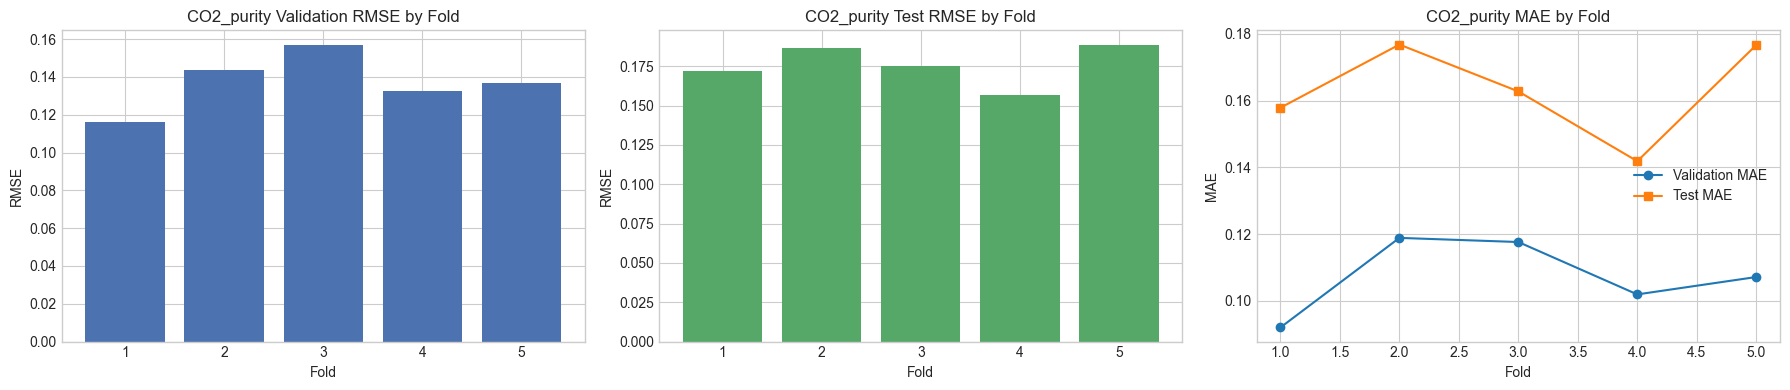

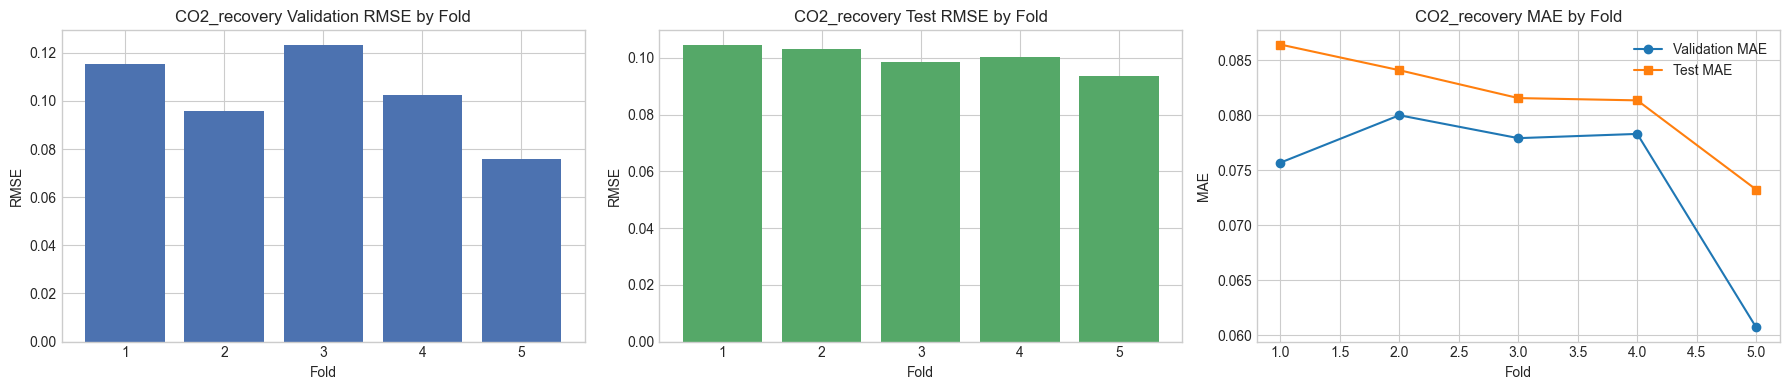

In [8]:
for target_col, result in results_by_target.items():
    plot_fold_metrics(target_col, result["fold_df"])


## 9. Test-Set Diagnostic Plots

고정 테스트셋에 대해 실제값/예측값 비교, residual 분포, residual 패턴을 확인합니다.

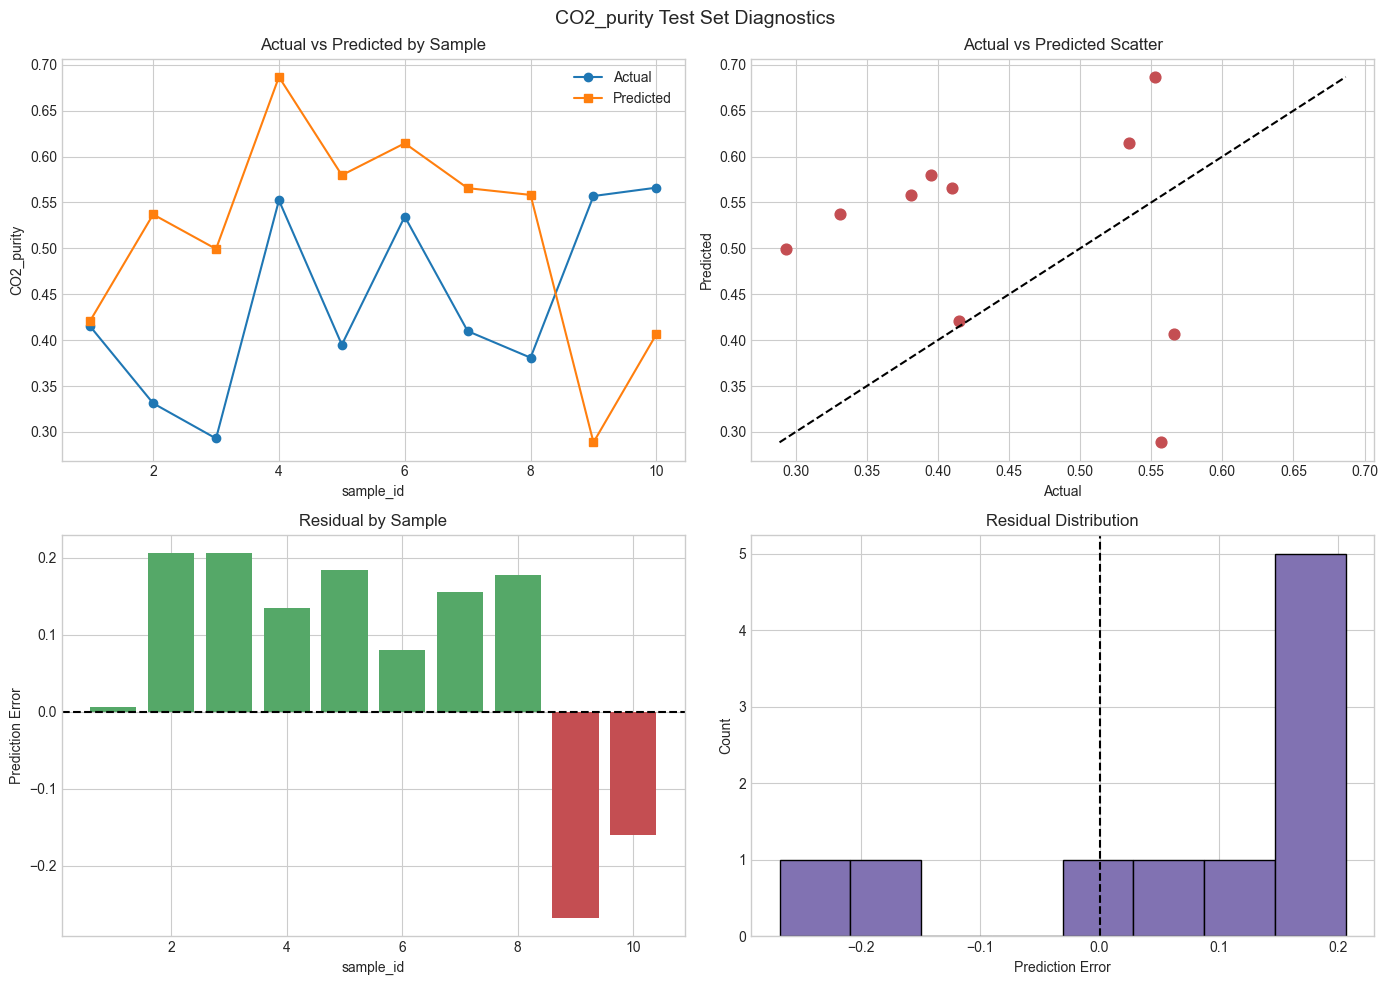

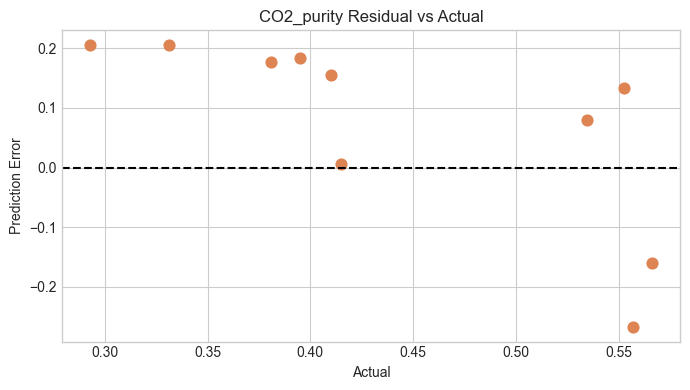

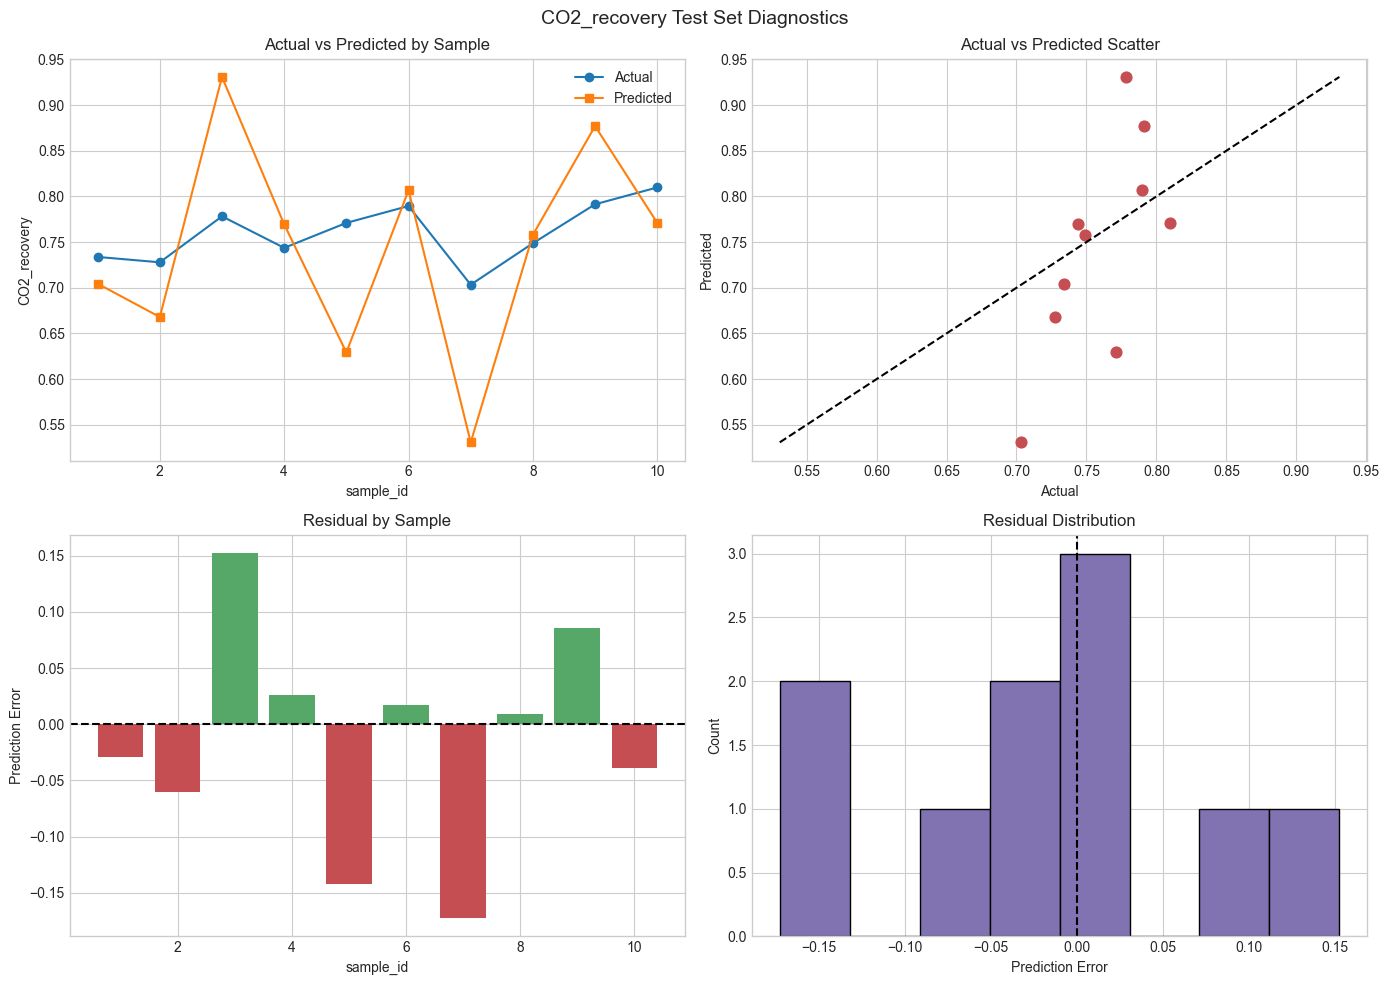

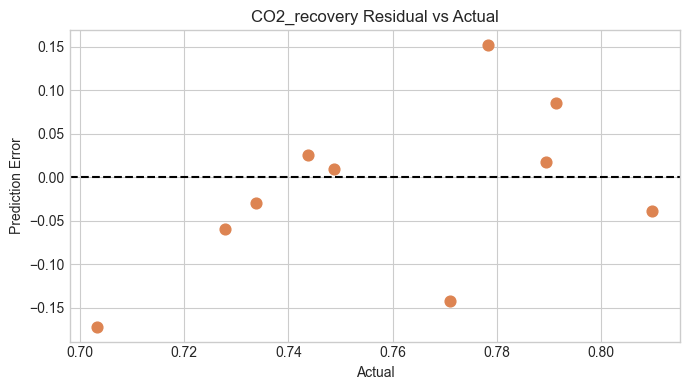

In [9]:
for target_col, result in results_by_target.items():
    pred_df = result["best_fold_payload"]["prediction_df"]
    plot_test_predictions(target_col, pred_df)
    plot_error_vs_actual(target_col, pred_df)


## 10. Learning Curves

best fold 기준 warm-up / fine-tuning 단계의 학습 곡선을 확인합니다.

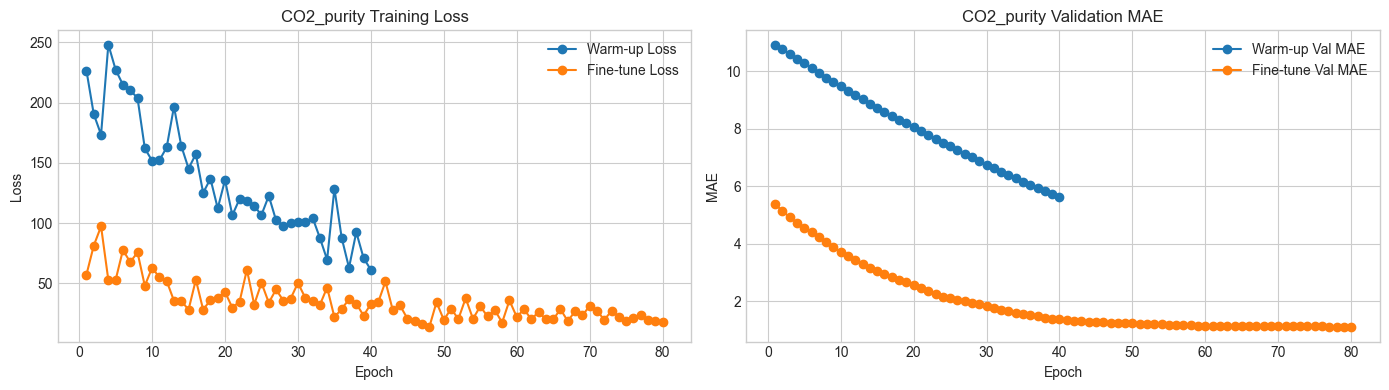

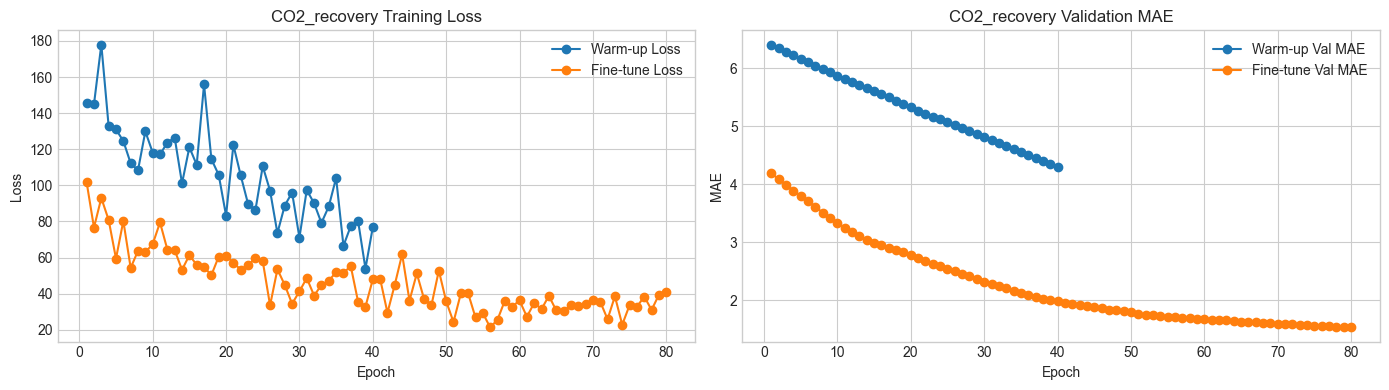

In [10]:
for target_col, result in results_by_target.items():
    history = result["best_fold_payload"]["history"]
    plot_learning_history(target_col, history)
